# 08 — Monitoring & Détection de Dérive en Production
## Projet EDF — Maintien de la Qualité du Modèle en Production

Ce notebook illustre le système de monitoring mis en place pour détecter et réagir à la **dérive du modèle** en production.

## Pourquoi surveiller la dérive ?

Un modèle ML peut se dégrader dans le temps sans qu'on le sache, car :
- La consommation électrique change (COVID-19, nouvelles industries, changement climatique)
- La distribution des températures évolue
- Le comportement des consommateurs change

## 3 méthodes de détection

| Méthode | Détecte | Seuil d'alerte |
|---------|---------|----------------|
| **KS Test** | Dérive des features (data drift) | ≥ 30% des features avec p < 0.05 |
| **PSI** | Dérive des prédictions | PSI ≥ 0.20 |
| **CUSUM** | Biais systématique cumulatif | Dépassement de 5σ |

**Plan :**
1. Simulation d'un scénario de dérive (impact COVID-19)
2. Application des 3 méthodes de détection
3. Visualisation des alertes
4. Processus de réentraînement

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from monitoring.drift import ks_test_drift, psi_drift, cusum_drift, full_drift_analysis
from models.evaluate import mape, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110})

PROCESSED_PATH = Path('../data/processed')
MODELS_PATH    = Path('../data/models_saved')
print('Imports OK')

Imports OK


## 1. Chargement du modèle de référence

In [2]:
X_train = np.load(PROCESSED_PATH / 'X_train.npy')
X_test  = np.load(PROCESSED_PATH / 'X_test.npy')
y_test  = np.load(PROCESSED_PATH / 'y_test.npy')

rf = joblib.load(MODELS_PATH / 'random_forest_v1.pkl')
y_pred_ref = rf.predict(X_test)

print(f'Modèle de référence : Random Forest')
print(f'MAPE baseline : {mape(y_test, y_pred_ref):.2f}%')
print(f'R² baseline   : {r2_score(y_test, y_pred_ref):.4f}')

Modèle de référence : Random Forest
MAPE baseline : 1.71%
R² baseline   : 0.9954


## 2. Simulation d'un scénario de dérive — Impact COVID-19

En mars 2020, la consommation électrique a chuté de ~15-20% suite au premier confinement. Ce type d'événement cause une dérive soudaine qu'un système de monitoring doit détecter rapidement.

In [3]:
# Simulation de 3 scénarios de dérive progressive
rng = np.random.default_rng(42)

# Scénario 1 : Pas de dérive (données normales)
X_stable = X_test + rng.normal(0, 0.05, X_test.shape)  # Bruit minimal

# Scénario 2 : Dérive modérée (changement saisonnier inhabituel)
X_moderate = X_test.copy()
X_moderate[:, :4] += rng.normal(0.5, 0.2, (len(X_test), 4))  # Features lag shiftées

# Scénario 3 : Dérive sévère (COVID-19 — chute de consommation)
X_covid = X_test.copy()
X_covid += rng.normal(2.0, 0.5, X_test.shape)  # Shift massif sur toutes les features

# Prédictions sur les 3 scénarios
y_pred_stable   = rf.predict(X_stable)
y_pred_moderate = rf.predict(X_moderate)
y_pred_covid    = rf.predict(X_covid)

print('Scénarios simulés :')
print(f'  Stable   → MAPE (vs baseline) : {mape(y_pred_ref, y_pred_stable):.2f}%')
print(f'  Modéré   → MAPE (vs baseline) : {mape(y_pred_ref, y_pred_moderate):.2f}%')
print(f'  COVID    → MAPE (vs baseline) : {mape(y_pred_ref, y_pred_covid):.2f}%')

Scénarios simulés :
  Stable   → MAPE (vs baseline) : 0.65%
  Modéré   → MAPE (vs baseline) : 4.90%
  COVID    → MAPE (vs baseline) : 27.74%


## 3. Application des 3 méthodes de détection

In [5]:
scenarios = {
    'Stable':  (X_stable,   y_pred_stable,   y_pred_stable - y_test),
    'Modéré':  (X_moderate, y_pred_moderate, y_pred_moderate - y_test),
    'COVID':   (X_covid,    y_pred_covid,    y_pred_covid - y_test),
}

all_reports = {}

for name, (X_cur, y_pred_cur, errors) in scenarios.items():
    print('='*55)
    print(f'SCÉNARIO : {name}')
    print('='*55)

    ks    = ks_test_drift(X_train, X_cur)
    psi   = psi_drift(y_pred_ref, y_pred_cur)
    cusum = cusum_drift(errors)

    print(ks)
    print(psi)
    print(cusum)

    all_reports[name] = full_drift_analysis(
        X_train, X_cur, y_pred_ref, y_pred_cur, errors
    )
    print(f'\n→ {all_reports[name]["global_recommendation"]}')

SCÉNARIO : Stable
[KS Test]  DÉRIVE DÉTECTÉE | stat=1.0000 (seuil=0.3) | Réentraîner le modèle avec les données récentes.
[PSI]  Pas de dérive | stat=0.0044 (seuil=0.2) | Distribution stable — pas d'action.
[CUSUM]  DÉRIVE DÉTECTÉE | stat=5.3138 (seuil=5.0) | Biais cumulatif détecté — vérifier les données récentes et réentraîner.

→  Dérive confirmée — réentraînement urgent requis sous 48h.
SCÉNARIO : Modéré
[KS Test]  DÉRIVE DÉTECTÉE | stat=0.6429 (seuil=0.3) | Réentraîner le modèle avec les données récentes.
[PSI]  DÉRIVE DÉTECTÉE | stat=0.5939 (seuil=0.2) | Dérive significative — réentraîner le modèle.
[CUSUM]  DÉRIVE DÉTECTÉE | stat=83.2593 (seuil=5.0) | Biais cumulatif détecté — vérifier les données récentes et réentraîner.

→  Dérive confirmée — réentraînement urgent requis sous 48h.
SCÉNARIO : COVID
[KS Test]  DÉRIVE DÉTECTÉE | stat=1.0000 (seuil=0.3) | Réentraîner le modèle avec les données récentes.
[PSI]  DÉRIVE DÉTECTÉE | stat=10.0371 (seuil=0.2) | Dérive significative — rée

## 4. Visualisation — Dashboard de monitoring

C:\Users\leofo\AppData\Local\Temp\ipykernel_30048\2806219.py:45: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.tight_layout()
C:\Users\leofo\AppData\Local\Temp\ipykernel_30048\2806219.py:46: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig(PROCESSED_PATH / '22_monitoring_drift.png', dpi=150, bbox_inches='tight')
C:\Users\leofo\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


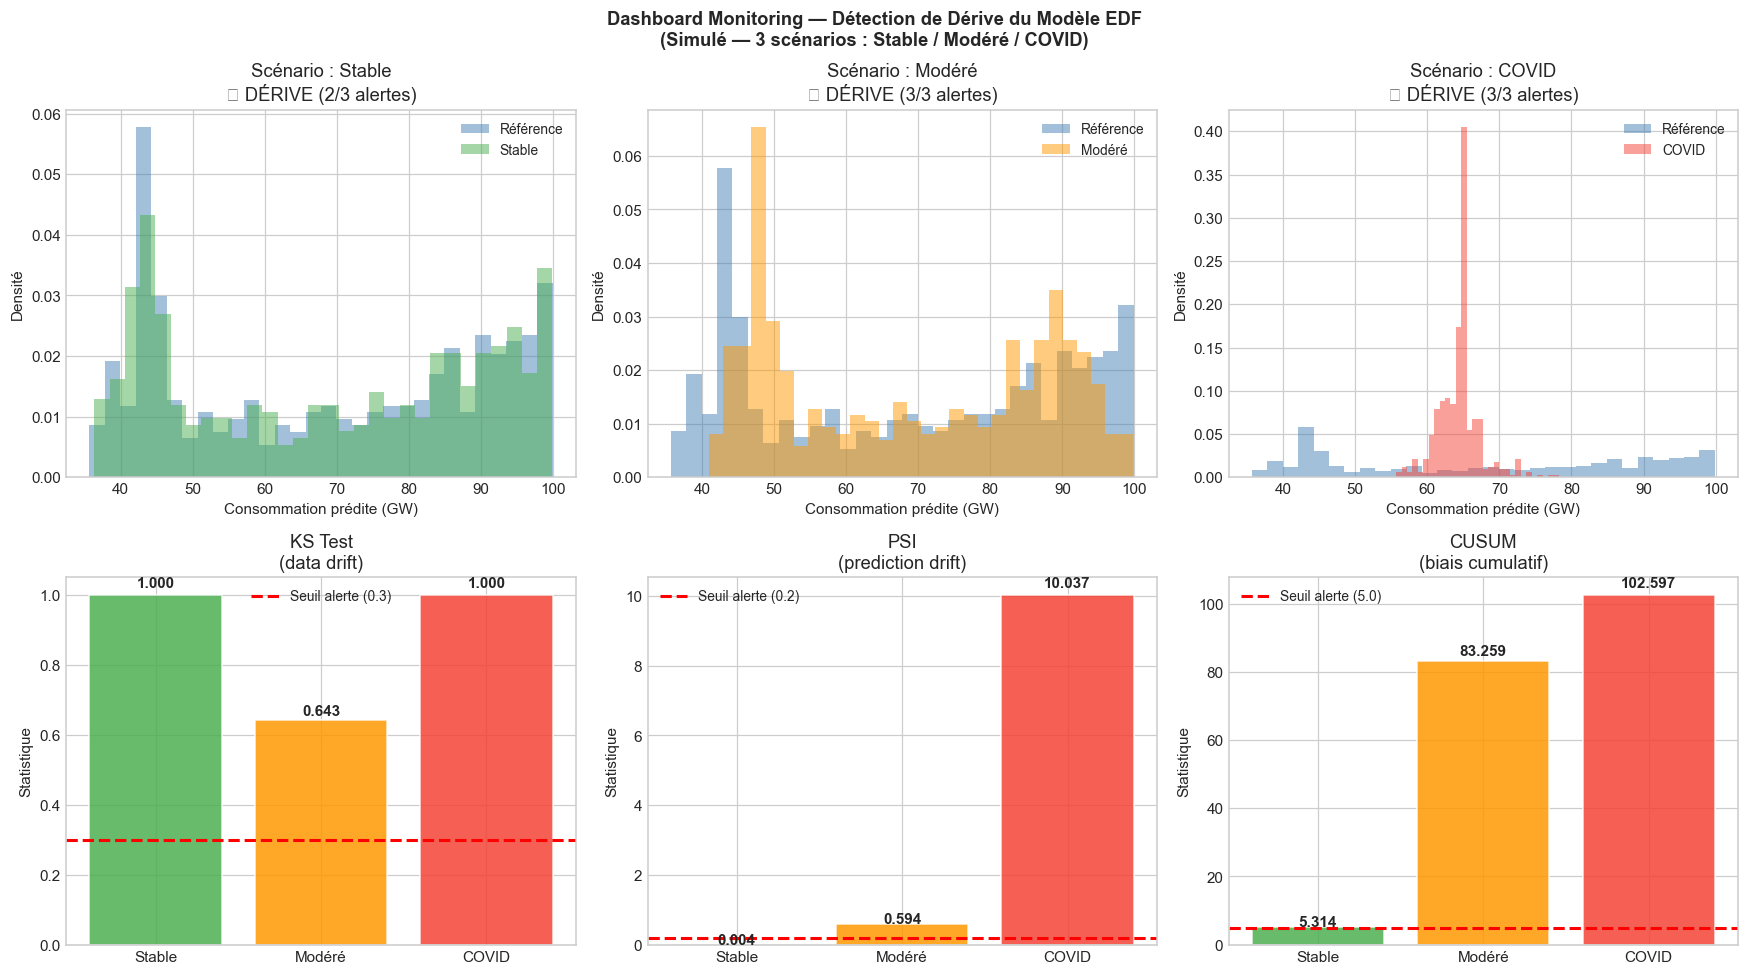

Dashboard sauvegardé.


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dashboard Monitoring — Détection de Dérive du Modèle EDF\n'
              '(Simulé — 3 scénarios : Stable / Modéré / COVID)', fontweight='bold', fontsize=12)

scenario_data = [
    ('Stable',  '#4CAF50', y_pred_stable),
    ('Modéré',  '#FF9800', y_pred_moderate),
    ('COVID',   '#F44336', y_pred_covid),
]

methods = ['ks_test', 'psi', 'cusum']
method_labels = ['KS Test\n(data drift)', 'PSI\n(prediction drift)', 'CUSUM\n(biais cumulatif)']
thresholds = [0.30, 0.20, 5.0]

# ── Ligne 1 : distributions des prédictions par scénario
for col, (name, color, y_pred_cur) in enumerate(scenario_data):
    ax = axes[0, col]
    ax.hist(y_pred_ref / 1000, bins=30, alpha=0.5, color='steelblue',
             label='Référence', density=True)
    ax.hist(y_pred_cur / 1000, bins=30, alpha=0.5, color=color,
             label=name, density=True)
    report = all_reports[name]
    drift_txt = '🔴 DÉRIVE' if report['drift_detected'] else '🟢 Stable'
    ax.set_title(f'Scénario : {name}\n{drift_txt} ({report["n_alerts"]}/3 alertes)')
    ax.set_xlabel('Consommation prédite (GW)')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=9)

# ── Ligne 2 : scores par méthode et par scénario
for col, (method, label, threshold) in enumerate(zip(methods, method_labels, thresholds)):
    ax = axes[1, col]
    stats_vals = [all_reports[s][method]['stat'] for s, _, _ in scenario_data]
    colors_bar = ['#4CAF50', '#FF9800', '#F44336']
    bars = ax.bar([s for s, _, _ in scenario_data], stats_vals,
                   color=colors_bar, alpha=0.85, edgecolor='white')
    ax.axhline(threshold, color='red', linestyle='--', linewidth=2,
                label=f'Seuil alerte ({threshold})')
    ax.set_title(label)
    ax.set_ylabel('Statistique')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, stats_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(PROCESSED_PATH / '22_monitoring_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard sauvegardé.')

## 5. Processus de réentraînement automatisé

Quand une dérive est détectée (≥ 2 alertes sur 3), le processus suivant est déclenché :

In [7]:
print('''
╔══════════════════════════════════════════════════════════════╗
║         PROCESSUS DE RÉENTRAÎNEMENT AUTOMATISÉ EDF          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DÉCLENCHEUR : ≥ 2 alertes détectées (KS / PSI / CUSUM)    ║
║                                                              ║
║  ÉTAPES AUTOMATIQUES (< 2h) :                               ║
║  1. Alerte Slack → équipe IA                                ║
║  2. Collecte données RTE (90 derniers jours)               ║
║  3. Réentraînement Random Forest (train.py --model rf)      ║
║  4. Évaluation : MAPE < 4% sur validation ?                 ║
║     ├── OUI → Push MLflow + déploiement blue-green          ║
║     └── NON → Alerte P1 → intervention humaine              ║
║  5. Monitoring 48h renforcé post-déploiement                ║
║                                                              ║
║  SLA : Délai maximum avant résolution = 4h                  ║
╚══════════════════════════════════════════════════════════════╝
''')

print('Fréquence de surveillance par environnement :')
print('  Production (Random Forest) → Toutes les 24h automatique')
print('  Staging                    → Toutes les 48h')
print('  Revue humaine              → Mensuelle (rapport Grafana)')


╔══════════════════════════════════════════════════════════════╗
║         PROCESSUS DE RÉENTRAÎNEMENT AUTOMATISÉ EDF          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DÉCLENCHEUR : ≥ 2 alertes détectées (KS / PSI / CUSUM)    ║
║                                                              ║
║  ÉTAPES AUTOMATIQUES (< 2h) :                               ║
║  1. Alerte Slack → équipe IA                                ║
║  2. Collecte données RTE (90 derniers jours)               ║
║  3. Réentraînement Random Forest (train.py --model rf)      ║
║  4. Évaluation : MAPE < 4% sur validation ?                 ║
║     ├── OUI → Push MLflow + déploiement blue-green          ║
║     └── NON → Alerte P1 → intervention humaine              ║
║  5. Monitoring 48h renforcé post-déploiement                ║
║                                                              ║
║  SLA : Délai maximum avant résolut